# Logistic Regression — Classification de radiographies thoraciques

Ce notebook présente l’entraînement et l’évaluation d’un modèle de Logistic Regression pour classifier des radiographies thoraciques en trois classes : NORMAL, BACTERIA et VIRUS.

L’objectif est de construire une approche de machine learning classique, simple et interprétable, afin d’évaluer ses performances sur le dataset du projet Zoidberg 2.0.

Le notebook utilise le preprocessing commun du groupe à travers la fonction `get_data_pipeline(augment=False)`. À partir de ce preprocessing commun, une extraction de caractéristiques spécifique à la Logistic Regression est appliquée afin de transformer les radiographies en vecteurs numériques exploitables par le modèle.

Le notebook couvre les étapes suivantes :

* chargement du dataset avec le preprocessing commun du groupe ;
* extraction de caractéristiques adaptée à la Logistic Regression ;
* standardisation des données ;
* validation croisée commune ;
* recherche d’hyperparamètres ;
* entraînement d’une Logistic Regression ;
* comparaison entre pixels aplatis et PCA ;
* évaluation finale sur le test set ;
* sauvegarde des résultats, des graphiques et des modèles.


# Questions de recherche

Ce notebook cherche à répondre aux questions suivantes :

1. La Logistic Regression peut-elle classifier correctement les radiographies thoraciques en trois classes : NORMAL, BACTERIA et VIRUS ?
2. Quel est l’impact de la réduction de dimension par PCA sur les performances du modèle, en validation croisée et sur le jeu de test final ?
3. Quelle configuration d’hyperparamètres offre le meilleur compromis entre performance, stabilité et capacité de généralisation ?

Les réponses à ces questions sont apportées à travers le preprocessing commun du groupe, l’extraction de caractéristiques adaptée à la Logistic Regression, la validation croisée, la recherche d’hyperparamètres, les métriques finales et l’analyse de la matrice de confusion.


# Cellule 1 — Imports et authentification

Cette première cellule regroupe l’ensemble des bibliothèques nécessaires au notebook.

Elle importe les outils utilisés pour :

* utiliser le preprocessing commun du groupe ;
* manipuler les tenseurs avec PyTorch ;
* transformer les données en tableaux numériques avec NumPy ;
* entraîner une Logistic Regression avec scikit-learn ;
* appliquer une standardisation des données avec `StandardScaler` ;
* utiliser une réduction de dimension avec PCA ;
* calculer les métriques d’évaluation ;
* générer les graphiques avec Matplotlib ;
* sauvegarder les modèles et les résultats d’expérience.

Le notebook utilise également les fonctions du fichier commun de preprocessing, notamment `get_data_pipeline`, afin de charger les données de manière cohérente avec le reste du projet.

L’authentification Hugging Face est gérée par le preprocessing commun, qui charge le token depuis le fichier `.env`. Ce token est nécessaire car le dataset utilisé dans le projet est privé.


In [65]:

# Cellule 1 — Imports & Token


import os
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import joblib

import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from cross_validation import load_folds

import torch
import torch.nn.functional as F

from ipynb.fs.full.preprocessing import get_data_pipeline, LABEL_NAMES

import json
from pathlib import Path
from datetime import datetime


from datasets import load_dataset
from PIL import Image

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# Charger les variables d'environnement (.env)
load_dotenv()

# Récupérer le token Hugging Face
hf_token = os.getenv("KEY_HUGGING_FACE")

if hf_token is None:
    raise ValueError("HF token not found. Vérifie ton fichier .env")

print("Token loaded successfully!")

Token loaded successfully!


# Cellule 2 — Chargement du dataset avec le preprocessing commun

Cette cellule permet de charger le dataset du projet en utilisant le preprocessing commun défini par le groupe.

Le dataset contient des radiographies thoraciques réparties en trois classes :

* **NORMAL** : radiographies sans pneumonie visible ;
* **BACTERIA** : radiographies associées à une pneumonie bactérienne ;
* **VIRUS** : radiographies associées à une pneumonie virale.

Le chargement est effectué à partir de la fonction `get_data_pipeline(augment=False)`, issue du fichier commun de preprocessing. Ce choix permet d’utiliser le même point d’entrée que les autres modèles du projet, tout en désactivant les augmentations aléatoires pour conserver une évaluation stable et reproductible avec la Logistic Regression.

La fonction renvoie plusieurs vues du dataset. Dans ce notebook, les vues utilisées sont :

* `train_pool_eval_view` : ensemble `train + validation` avec le preprocessing d’évaluation commun ;
* `test_view` : ensemble de test final avec le preprocessing d’évaluation commun ;
* `train_pool_raw` : version brute du train pool ;
* `test_raw` : version brute du test set.

Le `train_pool_data` est utilisé pour l’entraînement et la validation croisée. Le `test_data` est conservé séparément et utilisé uniquement pour l’évaluation finale du modèle.

Cette cellule affiche également le nombre d’images disponibles dans le train pool et dans le test set, ainsi que les noms des classes, afin de vérifier que le chargement s’est correctement déroulé.


In [ ]:

# Cellule 2 — Chargement du dataset avec le preprocessing commun


print("Loading dataset with common preprocessing pipeline...")

pipe = get_data_pipeline(augment=False)

train_pool_data = pipe["train_pool_eval_view"]
test_data = pipe["test_view"]

train_pool_raw = pipe["train_pool_raw"]
test_raw = pipe["test_raw"]

CLASS_NAMES = [
    LABEL_NAMES[0].upper(),
    LABEL_NAMES[1].upper(),
    LABEL_NAMES[2].upper()
]

print("\nDataset loaded successfully with common preprocessing!")
print(f"Train pool: {len(train_pool_data)} images")
print(f"Test: {len(test_data)} images")

print("\nClasses:")
print(CLASS_NAMES)

Loading dataset with common preprocessing pipeline...

Dataset loaded successfully with common preprocessing!
Train pool: 5227 images
Test: 624 images

Classes:
['NORMAL', 'BACTERIA', 'VIRUS']


# Cellule 3 — Extraction de caractéristiques depuis le preprocessing commun

Cette cellule transforme les images issues du preprocessing commun du groupe en matrices numériques exploitables par la Logistic Regression.

La Logistic Regression ne peut pas utiliser directement les images sous forme de tenseurs. Chaque radiographie doit donc être convertie en vecteur de caractéristiques numériques.

Le preprocessing commun renvoie des images sous forme de tenseurs PyTorch. Une extraction de caractéristiques spécifique à la Logistic Regression est ensuite appliquée.

Les étapes sont les suivantes :

1. récupération de l’image déjà transformée par le preprocessing commun ;
2. vérification que l’image est bien un tenseur PyTorch ;
3. conversion en niveaux de gris à partir des trois canaux ;
4. redimensionnement en **128 × 128 pixels** afin de limiter le nombre de caractéristiques ;
5. aplatissement de l’image en un vecteur numérique ;
6. récupération du label associé à chaque image.

Après transformation, chaque radiographie devient un vecteur de :

**128 × 128 = 16 384 caractéristiques**

La fonction `extract_logreg_features_from_common_view` est utilisée pour appliquer cette extraction à un ensemble complet d’images.

Dans cette cellule, l’extraction est appliquée au `train_pool_data` et au `test_data`. Les dimensions finales des matrices sont ensuite affichées afin de vérifier que les données sont correctement préparées pour la suite du pipeline.


In [ ]:

# Cellule 3 — Feature extraction depuis le preprocessing commun


IMG_SIZE_LOGREG = (128, 128)

def extract_logreg_features_from_common_view(view, target_size=IMG_SIZE_LOGREG):
    """
    Transforme les images issues du preprocessing commun du groupe
    en matrices X et y adaptées à la Logistic Regression.

    Étapes :
    - récupération de l'image déjà transformée par le pipeline commun
    - conversion en niveaux de gris
    - redimensionnement en 128x128 pour réduire la dimension
    - flatten en vecteur
    """
    X = []
    y = []

    for example in view:
        img = example["image"]

        # Le preprocessing commun renvoie normalement un tensor PyTorch [C, H, W]
        if not torch.is_tensor(img):
            continue

        img = img.float()

        # Passage en niveaux de gris à partir des 3 canaux
        img = img.mean(dim=0, keepdim=True)

        # Redimensionnement en 128x128 pour limiter le nombre de features
        img = F.interpolate(
            img.unsqueeze(0),
            size=target_size,
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        X.append(img.flatten().numpy().astype(np.float32))
        y.append(example["label"])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    return X, y


print("Extracting Logistic Regression features from common preprocessing...")

X_pool, y_pool = extract_logreg_features_from_common_view(train_pool_data)
X_test, y_test = extract_logreg_features_from_common_view(test_data)

print("\nShapes:")
print("X_pool:", X_pool.shape)
print("y_pool:", y_pool.shape, "distribution:", np.unique(y_pool, return_counts=True))

print("X_test:", X_test.shape)
print("y_test:", y_test.shape, "distribution:", np.unique(y_test, return_counts=True))

Extracting Logistic Regression features from common preprocessing...

Shapes:
X_pool: (5227, 16384)
y_pool: (5227,) distribution: (array([0, 1, 2]), array([1349, 2536, 1342]))
X_test: (624, 16384)
y_test: (624,) distribution: (array([0, 1, 2]), array([234, 242, 148]))


# Cellule 4 — Standardisation des données

Cette cellule applique une standardisation aux données avec `StandardScaler`.

La Logistic Regression est sensible à l’échelle des variables.
Il est donc important de standardiser les caractéristiques afin que chaque pixel soit traité de manière plus homogène par le modèle.

Le `StandardScaler` est entraîné uniquement sur le train pool avec `fit_transform`.
Il est ensuite appliqué au jeu de test avec `transform`.

Cette méthode permet d’éviter toute fuite de données : le jeu de test n’est pas utilisé pour calculer les paramètres de standardisation.

À la fin de la cellule, les dimensions de `X_pool_s` et `X_test_s` sont affichées afin de vérifier que la transformation a bien été appliquée.


In [68]:

# Cellule 4 — StandardScaler


scaler = StandardScaler()
X_pool_s = scaler.fit_transform(X_pool)
X_test_s = scaler.transform(X_test)

print("Scaling done!")
print("X_pool_s:", X_pool_s.shape)
print("X_test_s:", X_test_s.shape)

Scaling done!
X_pool_s: (5227, 16384)
X_test_s: (624, 16384)


# Cellule — Experiment Logger

Cette cellule met en place un système de suivi des expériences.

L’objectif est de sauvegarder automatiquement les informations importantes de chaque entraînement dans un fichier JSON.
Cela permet de garder un historique clair des différentes expériences réalisées.

Pour chaque expérience, les informations suivantes sont enregistrées :

* l’identifiant de l’expérience ;
* la date d’exécution ;
* le modèle utilisé ;
* la configuration du modèle ;
* les scores de validation ;
* les scores de test ;
* le dossier contenant les résultats générés.

Chaque expérience possède son propre dossier dans `../results/logistic_regression`.

Ce système permet de mieux organiser les résultats, de retrouver facilement les graphiques générés et de comparer les différentes versions du modèle, notamment la version avec pixels bruts et la version avec PCA.


In [69]:

# Cellule — Experiment Logger


RESULT_DIR = Path("../results/logistic_regression")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

JSON_PATH = RESULT_DIR / "results_history.json"

def load_experiments():
    if JSON_PATH.exists():
        with open(JSON_PATH, "r", encoding="utf-8") as f:
            return json.load(f)
    return []

def get_next_experiment_id():
    experiments = load_experiments()
    return len(experiments) + 1

def save_experiment(config, scores_test, scores_val=None):
    experiments = load_experiments()
    experiment_id = get_next_experiment_id()

    exp_dir = RESULT_DIR / f"experiment_{experiment_id}"
    exp_dir.mkdir(exist_ok=True)

    experiment = {
        "experiment_id": experiment_id,
        "date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model": "LogisticRegression",
        "config": config,
        "scores_validation": scores_val,
        "scores_test": scores_test,
        "result_folder": str(exp_dir)
    }

    experiments.append(experiment)

    with open(JSON_PATH, "w", encoding="utf-8") as f:
        json.dump(experiments, f, indent=4)

    print(f"Experiment {experiment_id} saved in JSON.")
    return experiment_id, exp_dir

# Cellule — Fonction d’évaluation multi-classe

Cette cellule définit la fonction `evaluate_multiclass`.

Cette fonction permet d’évaluer un modèle de classification multi-classe de manière complète et cohérente.
Elle est utilisée à plusieurs moments du notebook, notamment pendant la validation croisée, l’évaluation finale du modèle sans PCA et l’évaluation du modèle avec PCA.

La fonction calcule les métriques suivantes :

* **Accuracy** ;
* **Precision macro** ;
* **Recall macro** ;
* **F1-score macro** ;
* **ROC-AUC macro**.

Elle affiche également :

* la matrice de confusion ;
* le rapport de classification détaillé pour les classes **NORMAL**, **BACTERIA** et **VIRUS**.

L’utilisation des moyennes macro est importante dans ce projet, car elle permet de donner le même poids à chaque classe, même si le dataset est déséquilibré.

Cette fonction centralise donc toute la logique d’évaluation afin d’obtenir des résultats comparables entre les différentes expériences.


In [70]:

# Cellule — Fonction d'évaluation multi-classe


def evaluate_multiclass(name, model, Xs, y_true, class_names):
    """
    Évalue un modèle multi-classe avec les métriques principales :
    Accuracy, Precision, Recall, F1-score et ROC-AUC.
    """
    y_pred = model.predict(Xs)
    y_proba = model.predict_proba(Xs)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    auc = roc_auc_score(
        y_true_bin,
        y_proba,
        average="macro",
        multi_class="ovr"
    )

    print(f"\n===== {name} =====")
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

    print(
        "\nClassification report:\n",
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            digits=4
        )
    )

    scores = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": auc
    }

    print("\nScores:")
    for k, v in scores.items():
        print(f"- {k}: {v:.4f}")

    return scores

# Cellule — Validation croisée commune du groupe

Cette cellule réalise la validation croisée du modèle Logistic Regression à partir des folds communs du projet.

Les folds sont chargés grâce à la fonction `load_folds`.
Ils ont été générés une seule fois afin que tous les modèles du projet utilisent exactement les mêmes séparations entre entraînement et validation.

Cette méthodologie permet de comparer les modèles de manière plus équitable.
Les différences de résultats observées proviennent ainsi des modèles eux-mêmes, et non d’un découpage différent des données.

Pour chaque fold :

1. les indices d’entraînement et de validation sont récupérés ;
2. les données correspondantes sont extraites depuis le train pool ;
3. une Logistic Regression est entraînée ;
4. le modèle est évalué sur le fold de validation ;
5. les scores obtenus sont sauvegardés dans `cv_scores`.

Le modèle utilise une régularisation L2, le solveur `saga`, le paramètre `C=0.01` et `class_weight="balanced"` afin de tenir compte du déséquilibre entre les classes.

À la fin de cette cellule, toutes les performances obtenues sur les folds sont disponibles pour être résumées dans la cellule suivante.


In [71]:

# Cellule — Cross Validation commune du groupe


folds_data = load_folds()
folds = folds_data["folds"]

print(f"{len(folds)} folds loaded")
print("Fold configuration:")
print(f"- K folds: {folds_data['k_folds']}")
print(f"- Seed: {folds_data['seed']}")
print(f"- Number of samples: {folds_data['n_samples']}")
print(f"- Label distribution: {folds_data['label_distribution']}")

cv_scores = []

for fold in folds:
    fold_id = fold["fold"]
    train_idx = fold["train_idx"]
    val_idx = fold["val_idx"]

    print(f"\n===== Fold {fold_id} =====")

    X_fold_train = X_pool_s[train_idx]
    y_fold_train = y_pool[train_idx]

    X_fold_val = X_pool_s[val_idx]
    y_fold_val = y_pool[val_idx]

    fold_model = LogisticRegression(
        max_iter=8000,
        solver="saga",
        class_weight="balanced",
        n_jobs=-1,
        C=0.01,
        penalty="l2"
    )

    fold_model.fit(X_fold_train, y_fold_train)

    fold_scores = evaluate_multiclass(
        name=f"CROSS VALIDATION FOLD {fold_id}",
        model=fold_model,
        Xs=X_fold_val,
        y_true=y_fold_val,
        class_names=CLASS_NAMES
    )

    cv_scores.append(fold_scores)

print("\nCross Validation completed!")

3 folds loaded
Fold configuration:
- K folds: 3
- Seed: 42
- Number of samples: 5227
- Label distribution: [1349, 2536, 1342]

===== Fold 1 =====

===== CROSS VALIDATION FOLD 1 =====
Confusion matrix:
 [[424   8  18]
 [ 26 623 196]
 [ 33 150 265]]

Classification report:
               precision    recall  f1-score   support

      NORMAL     0.8778    0.9422    0.9089       450
    BACTERIA     0.7977    0.7373    0.7663       845
       VIRUS     0.5532    0.5915    0.5717       448

    accuracy                         0.7527      1743
   macro avg     0.7429    0.7570    0.7490      1743
weighted avg     0.7556    0.7527    0.7531      1743


Scores:
- Accuracy: 0.7527
- Precision: 0.7429
- Recall: 0.7570
- F1-score: 0.7490
- ROC-AUC: 0.8848

===== Fold 2 =====

===== CROSS VALIDATION FOLD 2 =====
Confusion matrix:
 [[428   5  17]
 [ 14 615 216]
 [ 28 162 257]]

Classification report:
               precision    recall  f1-score   support

      NORMAL     0.9106    0.9511    0.930

# Cellule — Résumé de la validation croisée

Cette cellule permet de résumer les résultats obtenus pendant la validation croisée.

Les scores calculés sur chaque fold sont regroupés afin d’obtenir, pour chaque métrique :

* une moyenne ;
* un écart-type.

Les métriques analysées sont :

* Accuracy ;
* Precision macro ;
* Recall macro ;
* F1-score macro ;
* ROC-AUC macro.

La moyenne donne une estimation globale des performances du modèle pendant la validation croisée.
L’écart-type permet d’évaluer la stabilité du modèle d’un fold à l’autre.

Un écart-type faible signifie que les résultats sont proches entre les différents folds, ce qui indique que le modèle est relativement stable.

Le résumé obtenu dans cette cellule est ensuite utilisé dans le rapport pour présenter les performances moyennes de la Logistic Regression en validation croisée.


In [72]:

# Cellule — Cross Validation Summary


def summarize_cv_scores(cv_scores):
    metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

    summary = {}

    for metric in metrics:
        values = [score[metric] for score in cv_scores]
        summary[metric] = {
            "mean": float(np.mean(values)),
            "std": float(np.std(values))
        }

    print("\n===== CROSS VALIDATION SUMMARY =====")
    for metric, values in summary.items():
        print(f"{metric}: mean={values['mean']:.4f}, std={values['std']:.4f}")

    return summary

cv_summary = summarize_cv_scores(cv_scores)


===== CROSS VALIDATION SUMMARY =====
Accuracy: mean=0.7436, std=0.0087
Precision: mean=0.7336, std=0.0115
Recall: mean=0.7463, std=0.0113
F1-score: mean=0.7391, std=0.0113
ROC-AUC: mean=0.8809, std=0.0035


# Cellule — Recherche d’hyperparamètres Logistic Regression

Cette cellule permet de comparer plusieurs configurations de Logistic Regression afin d’identifier les paramètres les plus adaptés au modèle.

Les paramètres testés sont :

* le type de représentation utilisé : pixels aplatis ou PCA ;
* l’utilisation ou non d’une réduction de dimension ;
* la valeur du paramètre de régularisation `C` ;
* la régularisation L2.

Chaque configuration est évaluée avec les mêmes folds de validation croisée que ceux utilisés dans le reste du projet. Cette méthodologie permet de comparer les configurations de manière équitable et d’éviter qu’un découpage différent des données influence les résultats.

Pour chaque configuration, les métriques moyennes sont calculées :

* Accuracy ;
* Precision macro ;
* Recall macro ;
* F1-score macro ;
* ROC-AUC macro.

Le F1-score macro est utilisé comme critère principal d’analyse, car il permet de mesurer l’équilibre des performances entre les trois classes. Le ROC-AUC est également pris en compte lorsque plusieurs configurations obtiennent des résultats proches.

Le tableau final est sauvegardé afin de pouvoir être utilisé directement dans le rapport.

Cette recherche permet de comparer la version sans PCA et la version avec PCA en validation croisée. L’évaluation finale sur le test set permet ensuite de vérifier quelle représentation généralise le mieux sur des données jamais vues.


In [73]:

# Cellule — Recherche d'hyperparamètres Logistic Regression


import pandas as pd

configs = [
    {
        "config_id": 1,
        "features": "Pixels",
        "pca": False,
        "C": 0.01,
        "penalty": "l2"
    },
    {
        "config_id": 2,
        "features": "Pixels",
        "pca": False,
        "C": 0.1,
        "penalty": "l2"
    },
    {
        "config_id": 3,
        "features": "PCA",
        "pca": True,
        "C": 0.01,
        "penalty": "l2"
    },
    {
        "config_id": 4,
        "features": "PCA",
        "pca": True,
        "C": 0.1,
        "penalty": "l2"
    }
]

tuning_results = []

for config in configs:
    print(f"\n===============================")
    print(f"Testing config {config['config_id']}: {config}")
    print(f"===============================")

    fold_scores = []

    for fold in folds:
        fold_id = fold["fold"]
        train_idx = fold["train_idx"]
        val_idx = fold["val_idx"]

        X_fold_train = X_pool_s[train_idx]
        y_fold_train = y_pool[train_idx]

        X_fold_val = X_pool_s[val_idx]
        y_fold_val = y_pool[val_idx]

        # PCA uniquement si la configuration le demande
        if config["pca"]:
            fold_pca = PCA(n_components=0.95, random_state=42)
            X_fold_train_used = fold_pca.fit_transform(X_fold_train)
            X_fold_val_used = fold_pca.transform(X_fold_val)
        else:
            X_fold_train_used = X_fold_train
            X_fold_val_used = X_fold_val

        fold_model = LogisticRegression(
            max_iter=8000,
            solver="saga",
            class_weight="balanced",
            n_jobs=-1,
            C=config["C"],
            penalty=config["penalty"],
            random_state=42
        )

        fold_model.fit(X_fold_train_used, y_fold_train)

        scores = evaluate_multiclass(
            name=f"CONFIG {config['config_id']} - FOLD {fold_id}",
            model=fold_model,
            Xs=X_fold_val_used,
            y_true=y_fold_val,
            class_names=CLASS_NAMES
        )

        fold_scores.append(scores)

    result = {
        "Config": config["config_id"],
        "Features": config["features"],
        "PCA": config["pca"],
        "C": config["C"],
        "Penalty": config["penalty"],
        "Acc. moy.": np.mean([s["Accuracy"] for s in fold_scores]) * 100,
        "Prec. moy.": np.mean([s["Precision"] for s in fold_scores]) * 100,
        "Recall moy.": np.mean([s["Recall"] for s in fold_scores]) * 100,
        "F1 moy.": np.mean([s["F1-score"] for s in fold_scores]) * 100,
        "ROC-AUC moy.": np.mean([s["ROC-AUC"] for s in fold_scores]) * 100
    }

    tuning_results.append(result)

tuning_df = pd.DataFrame(tuning_results)

# Arrondir les résultats pour affichage propre
tuning_df_display = tuning_df.copy()
for col in ["Acc. moy.", "Prec. moy.", "Recall moy.", "F1 moy.", "ROC-AUC moy."]:
    tuning_df_display[col] = tuning_df_display[col].round(1)

print("\n===== Résultats recherche hyperparamètres =====")
display(tuning_df_display)

# Sauvegarde du tableau
tuning_df_display.to_csv(RESULT_DIR / "logreg_hyperparameter_search.csv", index=False)

print(f"Table saved: {RESULT_DIR / 'logreg_hyperparameter_search.csv'}")


Testing config 1: {'config_id': 1, 'features': 'Pixels', 'pca': False, 'C': 0.01, 'penalty': 'l2'}

===== CONFIG 1 - FOLD 1 =====
Confusion matrix:
 [[424   8  18]
 [ 27 624 194]
 [ 33 150 265]]

Classification report:
               precision    recall  f1-score   support

      NORMAL     0.8760    0.9422    0.9079       450
    BACTERIA     0.7980    0.7385    0.7671       845
       VIRUS     0.5556    0.5915    0.5730       448

    accuracy                         0.7533      1743
   macro avg     0.7432    0.7574    0.7493      1743
weighted avg     0.7558    0.7533    0.7535      1743


Scores:
- Accuracy: 0.7533
- Precision: 0.7432
- Recall: 0.7574
- F1-score: 0.7493
- ROC-AUC: 0.8848

===== CONFIG 1 - FOLD 2 =====
Confusion matrix:
 [[428   5  17]
 [ 14 613 218]
 [ 28 162 257]]

Classification report:
               precision    recall  f1-score   support

      NORMAL     0.9106    0.9511    0.9304       450
    BACTERIA     0.7859    0.7254    0.7545       845
       VIRUS

/Users/williamleite/Documents/projetepitech/pneumonia_logreg/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



===== CONFIG 2 - FOLD 2 =====
Confusion matrix:
 [[433   5  12]
 [ 33 585 227]
 [ 33 168 246]]

Classification report:
               precision    recall  f1-score   support

      NORMAL     0.8677    0.9622    0.9125       450
    BACTERIA     0.7718    0.6923    0.7299       845
       VIRUS     0.5072    0.5503    0.5279       447

    accuracy                         0.7256      1742
   macro avg     0.7156    0.7350    0.7234      1742
weighted avg     0.7287    0.7256    0.7252      1742


Scores:
- Accuracy: 0.7256
- Precision: 0.7156
- Recall: 0.7350
- F1-score: 0.7234
- ROC-AUC: 0.8734

===== CONFIG 2 - FOLD 3 =====
Confusion matrix:
 [[416  13  20]
 [ 38 612 196]
 [ 41 187 219]]

Classification report:
               precision    recall  f1-score   support

      NORMAL     0.8404    0.9265    0.8814       449
    BACTERIA     0.7537    0.7234    0.7382       846
       VIRUS     0.5034    0.4899    0.4966       447

    accuracy                         0.7158      1742
   

,Config,Features,PCA,C,Penalty,Acc. moy.,Prec. moy.,Recall moy.,F1 moy.,ROC-AUC moy.
0,1,Pixels,False,0.01,l2,74.3,73.3,74.6,73.9,88.1
1,2,Pixels,False,0.10,l2,72.7,71.4,73.1,72.1,87.3
2,3,PCA,True,0.01,l2,73.6,73.0,74.3,73.5,88.2
3,4,PCA,True,0.10,l2,73.0,72.2,73.7,72.8,87.8


Table saved: ../results/logistic_regression/logreg_hyperparameter_search.csv


# Cellule 5 — Entraînement de la Logistic Regression sans PCA

Cette cellule entraîne une première version du modèle Logistic Regression sur l’ensemble du train pool.

Le modèle est entraîné avec la meilleure configuration obtenue pour la version sans PCA :

* solveur `saga` ;
* régularisation L2 ;
* `C=0.01` ;
* `class_weight="balanced"` ;
* nombre maximal d’itérations fixé à 8000.

Le paramètre `class_weight="balanced"` permet de prendre en compte le déséquilibre entre les classes. Cela évite que le modèle favorise trop fortement une classe plus représentée dans le dataset.

Le modèle est entraîné sur `X_pool_s` et `y_pool`, c’est-à-dire sur les données du train pool après extraction de caractéristiques et standardisation.

À la fin de cette cellule, la version sans PCA du modèle est entraînée et prête à être évaluée sur le jeu de test. Cette version servira ensuite de point de comparaison avec la version utilisant la PCA.

In [74]:

# Cellule 5 — Logistic Regression (multiclass) avec le meilleur C


model = LogisticRegression(
    max_iter=8000,
    solver="saga",
    multi_class="multinomial",
    class_weight="balanced",
    n_jobs=-1,
    C=0.01,        
    penalty="l2"
)

print("Training Logistic Regression (C=0.01)...")

model.fit(X_pool_s, y_pool)

print("Training done!")

Training Logistic Regression (C=0.01)...


/Users/williamleite/Documents/projetepitech/pneumonia_logreg/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training done!


# Cellule 6 — Évaluation du modèle sans PCA

Cette cellule évalue la Logistic Regression entraînée sur les pixels aplatis standardisés, sans réduction de dimension par PCA.

L’évaluation est réalisée sur le jeu de test final, qui contient des images jamais utilisées pendant l’entraînement ni pendant la validation croisée.

La fonction `evaluate_multiclass` est utilisée pour calculer les métriques principales :

* Accuracy ;
* Precision macro ;
* Recall macro ;
* F1-score macro ;
* ROC-AUC macro.

Elle affiche également la matrice de confusion et le rapport de classification détaillé.

Les scores de validation affichés ensuite correspondent aux moyennes obtenues pendant la validation croisée. Cela permet de comparer les performances moyennes en validation avec les performances finales sur le test set.

Cette étape permet donc d’évaluer la capacité du modèle sans PCA à généraliser sur des données inédites.

In [75]:

# Cellule 6 — Evaluation (metrics + report)



# Évaluation finale sur le test set
scores_test = evaluate_multiclass(
    "TEST",
    model,
    X_test_s,
    y_test,
    CLASS_NAMES
)

# Scores de validation = moyenne de la cross-validation
scores_val = {
    metric: values["mean"]
    for metric, values in cv_summary.items()
}

print("\nValidation scores from Cross Validation:")
for k, v in scores_val.items():
    print(f"- {k}: {v:.4f}")


===== TEST =====
Confusion matrix:
 [[ 91  49  94]
 [  3 209  30]
 [  3  56  89]]

Classification report:
               precision    recall  f1-score   support

      NORMAL     0.9381    0.3889    0.5498       234
    BACTERIA     0.6656    0.8636    0.7518       242
       VIRUS     0.4178    0.6014    0.4931       148

    accuracy                         0.6234       624
   macro avg     0.6739    0.6180    0.5982       624
weighted avg     0.7090    0.6234    0.6147       624


Scores:
- Accuracy: 0.6234
- Precision: 0.6739
- Recall: 0.6180
- F1-score: 0.5982
- ROC-AUC: 0.8430

Validation scores from Cross Validation:
- Accuracy: 0.7436
- Precision: 0.7336
- Recall: 0.7463
- F1-score: 0.7391
- ROC-AUC: 0.8809


# Cellule 7 — Visualisation des scores en pourcentage

Cette cellule définit la fonction `plot_scores`.

Cette fonction permet de générer un graphique en barres à partir des scores d’un modèle. Les métriques sont converties en pourcentage afin de rendre les résultats plus lisibles.

Les métriques affichées sont :

* Accuracy ;
* Precision ;
* Recall ;
* F1-score ;
* ROC-AUC.

Chaque barre représente une métrique du modèle. La valeur exacte est affichée au-dessus de chaque barre afin de faciliter l’interprétation.

La fonction permet également de sauvegarder automatiquement le graphique dans le dossier de l’expérience. Les images générées peuvent ensuite être insérées directement dans le rapport.

Cette cellule sert donc à produire des visualisations claires et exploitables pour la documentation du projet.

In [76]:

# Cellule 7 — Bar chart (%) + Save


def plot_scores(scores, title, save_path=None):
    labels = list(scores.keys())
    values = [scores[k] * 100 for k in labels]

    plt.figure(figsize=(9, 5))
    bars = plt.bar(labels, values)

    plt.ylim(0, 100)
    plt.ylabel("Score (%)")
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)

    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val + 1,
            f"{val:.1f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Graph saved: {save_path}")

    plt.show()

# Save experiment — Version sans PCA

Cette cellule sauvegarde les résultats de l’expérience correspondant à la Logistic Regression entraînée sur les pixels aplatis standardisés, sans PCA.

La configuration du modèle est enregistrée dans un dictionnaire `config_pixels`. Ce dictionnaire contient les principaux paramètres utilisés :

* taille utilisée pour l’extraction de caractéristiques ;
* type de caractéristiques ;
* standardisation ;
* absence de PCA ;
* solveur ;
* régularisation ;
* valeur de `C` ;
* gestion du déséquilibre des classes.

La fonction `save_experiment` crée ensuite un nouveau dossier d’expérience et enregistre les scores dans le fichier `results_history.json`.

Enfin, un graphique des performances sur le test set est généré et sauvegardé dans le dossier de l’expérience.

Cette cellule permet donc de conserver une trace complète de la version sans PCA du modèle, utilisée ensuite pour comparer les résultats avec la version PCA.

Experiment 17 saved in JSON.
Graph saved: ../results/logistic_regression/experiment_17/logreg_pixels_test_scores.png


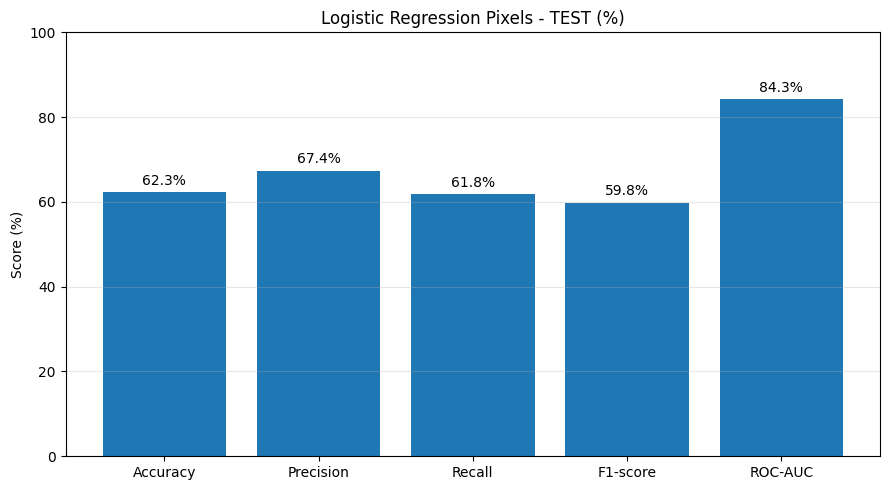

In [77]:

# Save experiment — Pixels


config_pixels = {
    "image_size": IMG_SIZE,
    "features": "raw_pixels_flatten",
    "scaler": "StandardScaler",
    "pca": False,
    "max_iter": 8000,
    "solver": "saga",
    "multi_class": "multinomial",
    "class_weight": "balanced",
    "C": 0.01,
    "penalty": "l2"
}

experiment_id_pixels, exp_dir_pixels = save_experiment(
    config=config_pixels,
    scores_val=scores_val,
    scores_test=scores_test
)

plot_scores(
    scores_test,
    "Logistic Regression Pixels - TEST (%)",
    save_path=exp_dir_pixels / "logreg_pixels_test_scores.png"
)

# Cellule — Feature Importance

Cette cellule génère des visualisations de feature importance pour la Logistic Regression sans PCA.

L’un des avantages de la Logistic Regression est son interprétabilité. Le modèle apprend un coefficient pour chaque caractéristique d’entrée. Dans cette version sans PCA, chaque caractéristique correspond à un pixel de l’image après extraction de caractéristiques.

Les coefficients appris peuvent donc être replacés sous forme d’image de taille **128 × 128** afin d’obtenir une carte d’importance pour chaque classe.

Une carte est générée pour chacune des trois classes :

* **NORMAL** ;
* **BACTERIA** ;
* **VIRUS**.

Les zones positives indiquent les pixels qui favorisent la prédiction de la classe étudiée. Les zones négatives indiquent au contraire les pixels qui défavorisent cette classe.

Ces visualisations permettent d’apporter une première forme d’interprétabilité au modèle. Elles doivent cependant être considérées comme une aide à la compréhension du comportement du modèle, et non comme une explication médicale complète.

Les cartes sont sauvegardées dans le dossier de l’expérience afin de pouvoir être utilisées dans le rapport.

Saved: ../results/logistic_regression/experiment_17/feature_importance_NORMAL.png


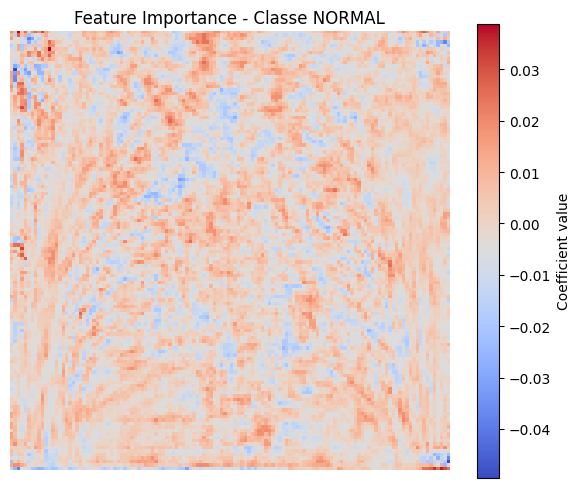

Saved: ../results/logistic_regression/experiment_17/feature_importance_BACTERIA.png


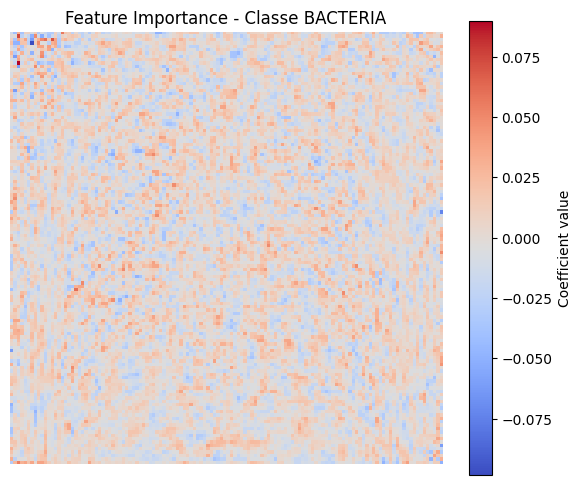

Saved: ../results/logistic_regression/experiment_17/feature_importance_VIRUS.png


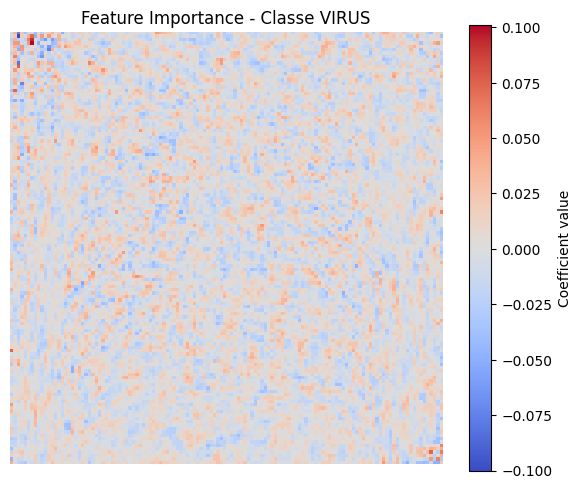

In [78]:

# Cellule — Feature Importance + Save


def save_logreg_feature_importance(model, img_size, class_names, save_dir):
    coefs = model.coef_

    for i, class_name in enumerate(class_names):
        importance_map = coefs[i].reshape(img_size)

        plt.figure(figsize=(6, 5))
        plt.imshow(importance_map, cmap="coolwarm")
        plt.colorbar(label="Coefficient value")
        plt.title(f"Feature Importance - Classe {class_name}")
        plt.axis("off")
        plt.tight_layout()

        save_path = save_dir / f"feature_importance_{class_name}.png"
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

        plt.show()

save_logreg_feature_importance(
    model=model,
    img_size=IMG_SIZE,
    class_names=CLASS_NAMES,
    save_dir=exp_dir_pixels
)

# Cellule 8 — Logistic Regression avec PCA

Cette cellule entraîne une seconde version du modèle Logistic Regression en ajoutant une réduction de dimension par PCA.

Le pipeline utilisé est le suivant :

**Pixels aplatis standardisés → PCA → Logistic Regression**

La PCA conserve **95 % de la variance** des données. Son objectif est de réduire la dimension de l’espace d’entrée tout en conservant l’essentiel de l’information contenue dans les radiographies.

Cette étape permet de limiter la redondance entre pixels, de réduire une partie du bruit et de fournir au modèle une représentation plus compacte des images.

La PCA est entraînée uniquement sur le train pool standardisé, puis appliquée au jeu de test. Le modèle Logistic Regression est ensuite entraîné sur les données transformées par PCA.

L’évaluation finale est réalisée sur le test set avec la fonction `evaluate_multiclass`.

Les scores et la configuration de cette expérience sont ensuite sauvegardés avec `save_experiment`, puis un graphique des performances est généré et enregistré.

Cette version avec PCA est comparée à la version sans PCA afin d’analyser l’impact de la réduction de dimension sur les performances du modèle et sur sa capacité de généralisation.

PCA dims: 16384 -> 453
Training Logistic Regression + PCA...
Training done!

===== TEST (PCA) =====
Confusion matrix:
 [[ 94  31 109]
 [  3 209  30]
 [  3  32 113]]

Classification report:
               precision    recall  f1-score   support

      NORMAL     0.9400    0.4017    0.5629       234
    BACTERIA     0.7684    0.8636    0.8132       242
       VIRUS     0.4484    0.7635    0.5650       148

    accuracy                         0.6667       624
   macro avg     0.7189    0.6763    0.6470       624
weighted avg     0.7568    0.6667    0.6605       624


Scores:
- Accuracy: 0.6667
- Precision: 0.7189
- Recall: 0.6763
- F1-score: 0.6470
- ROC-AUC: 0.8724
Experiment 18 saved in JSON.
Graph saved: ../results/logistic_regression/experiment_18/logreg_pca_test_scores.png


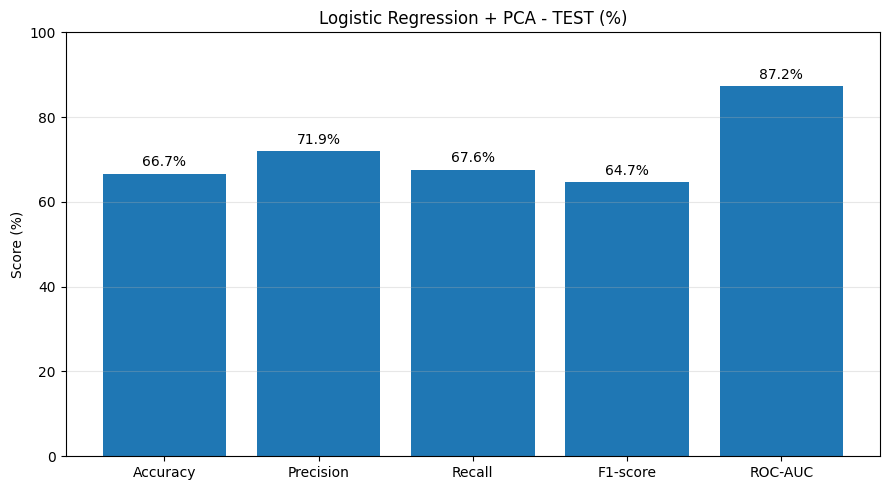

In [79]:

# Cellule 8 — PCA + Logistic Regression + Save experiment


pca = PCA(n_components=0.95, random_state=42)

# PCA entraînée sur tout le train pool
X_pool_pca = pca.fit_transform(X_pool_s)
X_test_pca = pca.transform(X_test_s)

print("PCA dims:", X_pool_s.shape[1], "->", X_pool_pca.shape[1])

model_pca = LogisticRegression(
    max_iter=8000,
    solver="saga",
    class_weight="balanced",
    n_jobs=-1,
    C=0.01,
    penalty="l2"
)

print("Training Logistic Regression + PCA...")
model_pca.fit(X_pool_pca, y_pool)
print("Training done!")

# Évaluation finale sur le test set uniquement
scores_test_pca = evaluate_multiclass(
    "TEST (PCA)",
    model_pca,
    X_test_pca,
    y_test,
    CLASS_NAMES
)

config_pca = {
    "image_size": IMG_SIZE,
    "features": "raw_pixels_flatten",
    "scaler": "StandardScaler",
    "pca": True,
    "pca_n_components": 0.95,
    "pca_output_dimensions": X_pool_pca.shape[1],
    "max_iter": 8000,
    "solver": "saga",
    "class_weight": "balanced",
    "C": 0.01,
    "penalty": "l2"
}

experiment_id_pca, exp_dir_pca = save_experiment(
    config=config_pca,
    scores_val=None,
    scores_test=scores_test_pca
)

plot_scores(
    scores_test_pca,
    "Logistic Regression + PCA - TEST (%)",
    save_path=exp_dir_pca / "logreg_pca_test_scores.png"
)

# Cellule — Matrice de confusion Logistic Regression + PCA

Cette cellule génère la matrice de confusion de la Logistic Regression avec PCA sur le jeu de test.

La matrice de confusion permet d’analyser plus précisément les erreurs du modèle. Elle indique, pour chaque classe réelle, combien d’images ont été correctement classées et combien ont été confondues avec une autre classe.

Dans ce projet, elle permet notamment d’observer les confusions entre les trois classes :

* **NORMAL** ;
* **BACTERIA** ;
* **VIRUS**.

Cette visualisation complète les métriques globales comme l’accuracy ou le F1-score. Elle permet de comprendre quelles classes sont les mieux reconnues et lesquelles posent le plus de difficultés au modèle.

Le graphique est sauvegardé dans le dossier de l’expérience PCA afin de pouvoir être inséré directement dans le rapport.

Confusion matrix saved: ../results/logistic_regression/experiment_18/confusion_matrix_logreg_pca.png


<Figure size 700x600 with 0 Axes>

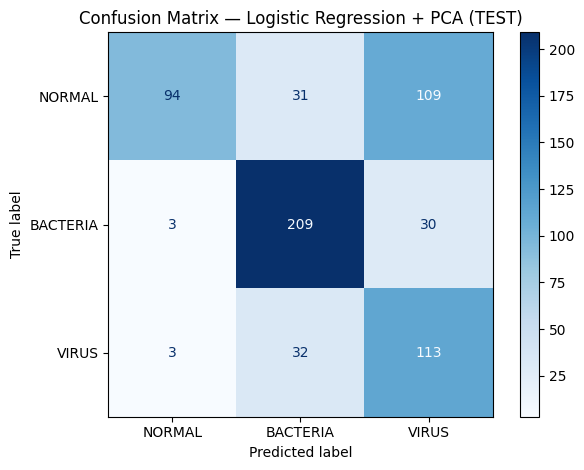

In [80]:

# Cellule — Confusion Matrix Logistic Regression + PCA


from sklearn.metrics import ConfusionMatrixDisplay

y_pred_pca = model_pca.predict(X_test_pca)

cm_pca = confusion_matrix(y_test, y_pred_pca)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pca,
    display_labels=CLASS_NAMES
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Logistic Regression + PCA (TEST)")
plt.tight_layout()

save_path = exp_dir_pca / "confusion_matrix_logreg_pca.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

print(f"Confusion matrix saved: {save_path}")

plt.show()

# Cellule 9 — Comparaison des modèles et sauvegarde

Cette cellule compare les performances des deux versions de la Logistic Regression :

* Logistic Regression sur pixels aplatis standardisés ;
* Logistic Regression avec PCA.

La fonction `compare_models_bar` génère un graphique en barres permettant de comparer les deux modèles sur les principales métriques :

* Accuracy ;
* Precision ;
* Recall ;
* F1-score ;
* ROC-AUC.

Cette comparaison permet d’évaluer l’impact de la PCA sur les performances du modèle.

La cellule sauvegarde ensuite les modèles entraînés avec `joblib` :

* le modèle Logistic Regression sans PCA ;
* le modèle Logistic Regression avec PCA ;
* le scaler utilisé pour standardiser les données ;
* l’objet PCA utilisé pour la réduction de dimension.

Ces fichiers sont enregistrés dans le dossier `models`. Cette sauvegarde permet de réutiliser les modèles plus tard sans devoir relancer tout l’entraînement.

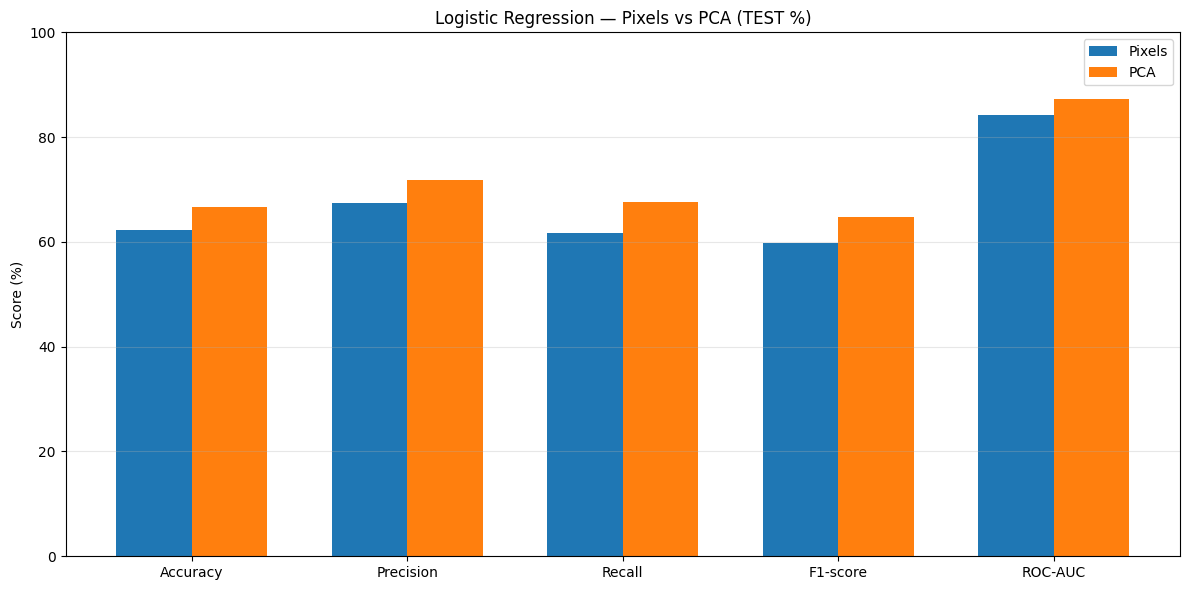

Saved models in pneumonia_logistic_regression/models/


In [81]:

# Cellule 9 — Compare + Save


def compare_models_bar(models_scores, title="Comparaison modèles (TEST %)"):
    metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
    names = list(models_scores.keys())

    x = np.arange(len(metrics))
    width = 0.35 if len(names) == 2 else 0.25

    plt.figure(figsize=(12, 6))
    for i, name in enumerate(names):
        vals = [models_scores[name][m] * 100 for m in metrics]
        plt.bar(x + i * width, vals, width=width, label=name)

    plt.xticks(x + width * (len(names)-1)/2, metrics)
    plt.ylim(0, 100)
    plt.ylabel("Score (%)")
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

compare_models_bar(
    {"Pixels": scores_test, "PCA": scores_test_pca},
    "Logistic Regression — Pixels vs PCA (TEST %)"
)


# Sauvegarde des modèles


MODEL_DIR = Path("models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(model, MODEL_DIR / "logreg_3classes_pixels.pkl")
joblib.dump(model_pca, MODEL_DIR / "logreg_3classes_pca.pkl")
joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
joblib.dump(pca, MODEL_DIR / "pca.pkl")

print("Saved models in pneumonia_logistic_regression/models/")

# Réponses aux questions de recherche

1. La Logistic Regression obtient des résultats corrects pour un modèle linéaire simple. La version avec PCA atteint une accuracy finale de **66,7 %** sur le test set, avec une precision macro de **71,9 %**, un recall macro de **67,6 %**, un F1-score macro de **64,7 %** et un ROC-AUC de **87,2 %**.

2. L’ajout de la PCA a un impact positif sur les performances finales du modèle sur le jeu de test. Même si la version sans PCA obtient des résultats légèrement supérieurs en validation croisée, la version avec PCA généralise mieux sur les données jamais vues. Elle améliore l’accuracy, la precision, le recall, le F1-score et le ROC-AUC par rapport à la version utilisant les pixels aplatis standardisés sans réduction de dimension.

3. La configuration retenue pour l’analyse finale est la Logistic Regression avec PCA, `C=0.01`, régularisation L2, solver `saga` et `class_weight="balanced"`. Cette configuration offre le meilleur compromis entre performance sur le test set, réduction de dimension, stabilité et capacité de généralisation.
